# Walk-forward validation (time series)

Goal: evaluate stability of conclusions across time by running a rolling-origin (walk-forward) protocol.

Protocol (default):

- choose yearly cutoffs
- train: all matches with `week < cutoff`
- test: matches in `[cutoff, cutoff + horizon)`

Models:

- baseline bookmaker implied probability (`ps_imp_p1`)
- Logistic Regression with odds
- Logistic Regression no-odds (sports-only)

Outputs:

- table with per-cutoff metrics
- plots (logloss and ROC AUC over cutoffs) saved to `figures/`


In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score

os.makedirs('figures', exist_ok=True)


In [2]:
ods = pd.read_parquet('ods.parquet')
tml = pd.read_parquet('tml.parquet')
players = pd.read_parquet('players.parquet')

ods['Date'] = pd.to_datetime(ods['Date'])
tml['tourney_date'] = pd.to_datetime(tml['tourney_date'].astype(str), format='%Y%m%d', errors='coerce')

(ods.shape, tml.shape, players.shape)


((22851, 42), (24939, 50), (7643, 12))

In [3]:
def key_from_odds(name: str) -> str:
    if pd.isna(name):
        return ''
    s = str(name).strip().lower()
    s = s.replace("'", '').replace('-', ' ')
    s = re.sub(r"\s+", ' ', s)
    parts = s.split(' ')
    if not parts:
        return ''
    init = re.sub(r"[^a-z]", '', parts[-1].replace('.', ''))[:1]
    surname = re.sub(r"[^a-z\s]", '', ' '.join(parts[:-1])).strip()
    return f"{surname} {init}".strip()


def key_from_tml(full_name: str) -> str:
    if pd.isna(full_name):
        return ''
    s = str(full_name).strip().lower()
    s = s.replace("'", '').replace('-', ' ')
    s = re.sub(r"\s+", ' ', s)
    parts = s.split(' ')
    if not parts:
        return ''
    if len(parts) == 1:
        return re.sub(r"[^a-z]", '', parts[0])
    init = re.sub(r"[^a-z]", '', parts[0])[:1]
    surname = re.sub(r"[^a-z\s]", '', ' '.join(parts[1:])).strip()
    return f"{surname} {init}".strip()


In [4]:
ods['week'] = (ods['Date'] - pd.to_timedelta(ods['Date'].dt.weekday, unit='D')).dt.normalize()
tml['week'] = tml['tourney_date'].dt.normalize()

ods['wkey'] = ods['Winner'].map(key_from_odds)
ods['lkey'] = ods['Loser'].map(key_from_odds)
tml['wkey'] = tml['winner_name'].map(key_from_tml)
tml['lkey'] = tml['loser_name'].map(key_from_tml)

ods['p1'] = ods[['wkey', 'lkey']].min(axis=1)
ods['p2'] = ods[['wkey', 'lkey']].max(axis=1)
tml['p1'] = tml[['wkey', 'lkey']].min(axis=1)
tml['p2'] = tml[['wkey', 'lkey']].max(axis=1)

joined = tml.merge(
    ods,
    how='inner',
    on=['week', 'p1', 'p2'],
    suffixes=('_tml', '_ods')
)

print('joined shape:', joined.shape)
print('match rate tml:', round(joined.shape[0] / tml.shape[0], 3))
print('match rate ods:', round(joined.shape[0] / ods.shape[0], 3))
joined.shape


joined shape: (17633, 99)
match rate tml: 0.707
match rate ods: 0.772


(17633, 99)

In [5]:
# Build symmetric match frame
joined = joined.copy()

joined['winner_key'] = joined['winner_name'].map(key_from_tml)
joined['loser_key'] = joined['loser_name'].map(key_from_tml)
joined['y_p1_win'] = (joined['winner_key'] == joined['p1']).astype(int)

# ranks
joined['rank_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank'], joined['loser_rank'])
joined['rank_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank'], joined['loser_rank'])
joined['rank_diff_p1_minus_p2'] = joined['rank_p1'] - joined['rank_p2']

joined['rank_points_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_diff_p1_minus_p2'] = joined['rank_points_p1'] - joined['rank_points_p2']

# odds for p1
joined['b365_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['B365W'], joined['B365L'])
joined['b365_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['B365W'], joined['B365L'])
joined['ps_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['PSW'], joined['PSL'])
joined['ps_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['PSW'], joined['PSL'])

for prefix in ['b365', 'ps']:
    op1 = joined[f'{prefix}_odds_p1']
    op2 = joined[f'{prefix}_odds_p2']
    p1 = 1.0 / op1
    p2 = 1.0 / op2
    s = p1 + p2
    joined[f'{prefix}_imp_p1'] = (p1 / s).where(np.isfinite(s), np.nan)
    joined[f'{prefix}_imp_p2'] = (p2 / s).where(np.isfinite(s), np.nan)

joined['match_date'] = joined['tourney_date']
joined['week'] = joined['week'].dt.normalize()

joined[['week','match_date','p1','p2','y_p1_win','ps_imp_p1','rank_diff_p1_minus_p2','surface']].head(3)


,week,match_date,p1,p2,y_p1_win,ps_imp_p1,rank_diff_p1_minus_p2,surface
0,2017-01-02,2017-01-02,nishioka y,troicki v,0,0.370192,71.0,Hard
1,2017-01-02,2017-01-02,edmund k,escobedo e,1,0.685144,-96.0,Hard
2,2017-01-02,2017-01-02,pouille l,simon g,1,0.502577,-10.0,Hard


In [6]:
def add_elo_features(df: pd.DataFrame, k: float = 32.0, init: float = 1500.0) -> pd.DataFrame:
    df0 = df.copy()
    if 'match_date' in df0.columns:
        df0 = df0.sort_values(['match_date', 'week', 'p1', 'p2'], kind='mergesort')
    else:
        df0 = df0.sort_values(['week', 'p1', 'p2'], kind='mergesort')

    rating_overall: dict[str, float] = {}
    rating_surface: dict[tuple[str, str], float] = {}

    elo_p1 = np.empty(len(df0), dtype=float)
    elo_p2 = np.empty(len(df0), dtype=float)
    elo_s_p1 = np.empty(len(df0), dtype=float)
    elo_s_p2 = np.empty(len(df0), dtype=float)

    def _exp(r_a: float, r_b: float) -> float:
        return 1.0 / (1.0 + 10.0 ** ((r_b - r_a) / 400.0))

    for i, row in enumerate(df0.itertuples(index=False)):
        p1 = getattr(row, 'p1')
        p2 = getattr(row, 'p2')
        y = int(getattr(row, 'y_p1_win'))
        surf = getattr(row, 'surface', None)
        if pd.isna(surf) or surf is None:
            surf = 'Unknown'
        else:
            surf = str(surf)

        r1 = rating_overall.get(p1, init)
        r2 = rating_overall.get(p2, init)
        elo_p1[i] = r1
        elo_p2[i] = r2

        rs1 = rating_surface.get((p1, surf), init)
        rs2 = rating_surface.get((p2, surf), init)
        elo_s_p1[i] = rs1
        elo_s_p2[i] = rs2

        e1 = _exp(r1, r2)
        e2 = 1.0 - e1
        s1 = float(y)
        s2 = 1.0 - s1

        rating_overall[p1] = r1 + k * (s1 - e1)
        rating_overall[p2] = r2 + k * (s2 - e2)

        es1 = _exp(rs1, rs2)
        es2 = 1.0 - es1
        rating_surface[(p1, surf)] = rs1 + k * (s1 - es1)
        rating_surface[(p2, surf)] = rs2 + k * (s2 - es2)

    df0['elo_p1'] = elo_p1
    df0['elo_p2'] = elo_p2
    df0['elo_diff_p1_minus_p2'] = df0['elo_p1'] - df0['elo_p2']

    df0['elo_surface_p1'] = elo_s_p1
    df0['elo_surface_p2'] = elo_s_p2
    df0['elo_surface_diff_p1_minus_p2'] = df0['elo_surface_p1'] - df0['elo_surface_p2']

    return df0


# Add ELO features once (online by time, no leakage)
joined = add_elo_features(joined, k=32.0, init=1500.0)


def build_preprocess(num_cols, cat_cols):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler(with_mean=False)),
    ])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols),
        ],
        remainder='drop'
    )


def eval_probs(y_true, p_pred):
    y_true = np.asarray(y_true, dtype=float)
    p_pred = np.asarray(p_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(p_pred)
    y_true = y_true[mask].astype(int)
    p_pred = p_pred[mask].clip(1e-6, 1 - 1e-6)

    return {
        'n': int(len(y_true)),
        'logloss': float(log_loss(y_true, p_pred)),
        'roc_auc': float(roc_auc_score(y_true, p_pred)),
        'acc@0.5': float(accuracy_score(y_true, p_pred >= 0.5)),
    }


def run_one_split(df: pd.DataFrame, cutoff: pd.Timestamp, horizon_days: int = 365):
    start = cutoff
    end = cutoff + pd.Timedelta(days=horizon_days)

    df0 = df.dropna(subset=['y_p1_win', 'week']).copy()
    train_df = df0[df0['week'] < start].copy()
    test_df = df0[(df0['week'] >= start) & (df0['week'] < end)].copy()

    if len(test_df) < 200 or len(train_df) < 500:
        return None

    y_train = train_df['y_p1_win'].astype(int)
    y_test = test_df['y_p1_win'].astype(int)

    rows = []

    # Baseline: PS implied probability
    if 'ps_imp_p1' in test_df.columns:
        rows.append({
            'model': 'baseline_ps_only',
            **eval_probs(y_test, test_df['ps_imp_p1']),
        })

    # Logistic regression with odds
    cols_odds = [c for c in ['ps_imp_p1', 'b365_imp_p1', 'surface'] if c in train_df.columns]
    if len(cols_odds) > 0:
        num_cols = [c for c in cols_odds if c != 'surface']
        cat_cols = ['surface'] if 'surface' in cols_odds else []
        pre = build_preprocess(num_cols, cat_cols)
        pipe = Pipeline(steps=[
            ('preprocess', pre),
            ('model', LogisticRegression(max_iter=10000, solver='saga', penalty='l2', n_jobs=-1)),
        ])
        X_train = train_df[cols_odds].copy()
        X_test = test_df[cols_odds].copy()
        for oc in ['ps_imp_p1', 'b365_imp_p1']:
            if oc in X_train.columns:
                X_train[oc] = X_train[oc].fillna(0.5)
                X_test[oc] = X_test[oc].fillna(0.5)
        pipe.fit(X_train, y_train)
        p = pipe.predict_proba(X_test)[:, 1]
        rows.append({
            'model': 'logreg_with_odds',
            **eval_probs(y_test, p),
        })

    # Logistic regression no-odds (baseline sports-only)
    cols_no = [c for c in ['rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2', 'surface'] if c in train_df.columns]
    if len(cols_no) > 0:
        num_cols = [c for c in cols_no if c != 'surface']
        cat_cols = ['surface'] if 'surface' in cols_no else []
        pre = build_preprocess(num_cols, cat_cols)
        pipe = Pipeline(steps=[
            ('preprocess', pre),
            ('model', LogisticRegression(max_iter=10000, solver='saga', penalty='l2', n_jobs=-1)),
        ])
        pipe.fit(train_df[cols_no], y_train)
        p = pipe.predict_proba(test_df[cols_no])[:, 1]
        rows.append({
            'model': 'logreg_no_odds',
            **eval_probs(y_test, p),
        })

    # Logistic regression no-odds + ELO (overall + surface)
    cols_elo = [
        'rank_diff_p1_minus_p2',
        'rank_points_diff_p1_minus_p2',
        'elo_diff_p1_minus_p2',
        'elo_surface_diff_p1_minus_p2',
        'surface',
    ]
    cols_elo = [c for c in cols_elo if c in train_df.columns]
    if len(cols_elo) > 0 and ('elo_diff_p1_minus_p2' in cols_elo):
        num_cols = [c for c in cols_elo if c != 'surface']
        cat_cols = ['surface'] if 'surface' in cols_elo else []
        pre = build_preprocess(num_cols, cat_cols)
        pipe = Pipeline(steps=[
            ('preprocess', pre),
            ('model', LogisticRegression(max_iter=10000, solver='saga', penalty='l2', n_jobs=-1)),
        ])
        pipe.fit(train_df[cols_elo], y_train)
        p = pipe.predict_proba(test_df[cols_elo])[:, 1]
        rows.append({
            'model': 'logreg_no_odds_elo',
            **eval_probs(y_test, p),
        })

    out = pd.DataFrame(rows)
    out['cutoff'] = start.date().isoformat()
    out['test_end'] = end.date().isoformat()
    return out


In [7]:
# Walk-forward settings
horizon_days = 365
cutoffs = pd.date_range('2019-01-01', '2025-01-01', freq='YS')
cutoffs


DatetimeIndex(['2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01',
               '2023-01-01', '2024-01-01', '2025-01-01'],
              dtype='datetime64[ns]', freq='YS-JAN')

In [8]:
rows = []
for c in cutoffs:
    res = run_one_split(joined, cutoff=pd.Timestamp(c), horizon_days=horizon_days)
    if res is None:
        continue
    rows.append(res)

wf = pd.concat(rows, ignore_index=True)
wf.sort_values(['cutoff','model']).reset_index(drop=True)


,model,n,logloss,roc_auc,acc@0.5,cutoff,test_end
0,baseline_ps_only,2107,0.595423,0.741160,0.671571,2019-01-01,2020-01-01
1,logreg_no_odds,2114,0.645750,0.667927,0.613056,2019-01-01,2020-01-01
2,logreg_no_odds_elo,2114,0.636880,0.684789,0.623463,2019-01-01,2020-01-01
3,logreg_with_odds,2114,0.598596,0.739839,0.667455,2019-01-01,2020-01-01
4,baseline_ps_only,1036,0.580063,0.760085,0.693050,2020-01-01,2020-12-31
5,logreg_no_odds,1042,0.638978,0.683245,0.632438,2020-01-01,2020-12-31
6,logreg_no_odds_elo,1042,0.626453,0.698657,0.631478,2020-01-01,2020-12-31
7,logreg_with_odds,1042,0.583077,0.758436,0.693858,2020-01-01,2020-12-31
8,baseline_ps_only,1877,0.587531,0.749663,0.685136,2021-01-01,2022-01-01
9,logreg_no_odds,1883,0.628237,0.694382,0.630377,2021-01-01,2022-01-01


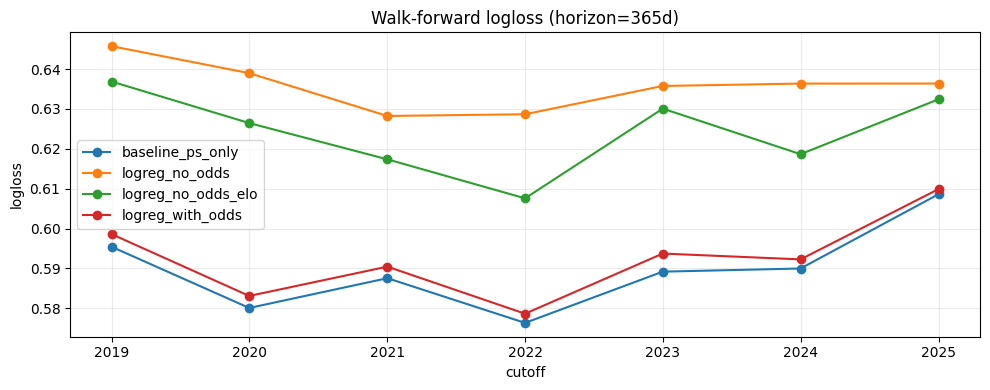

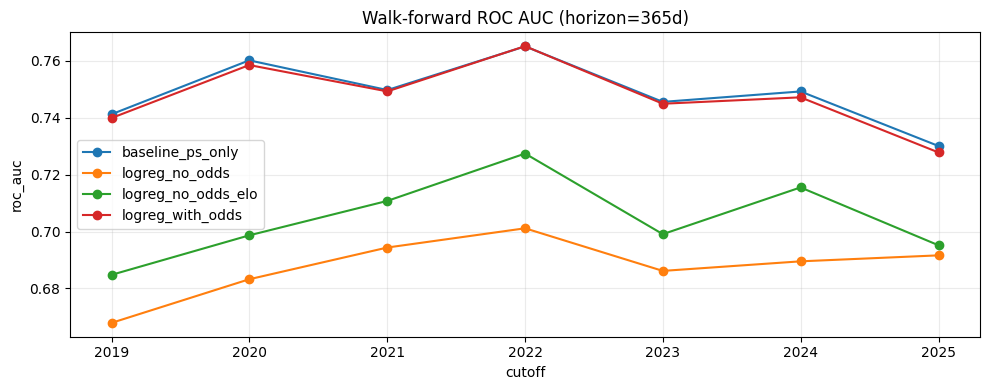

In [9]:
def plot_metric(wf: pd.DataFrame, metric: str, title: str, out_path: str):
    pivot = wf.pivot_table(index='cutoff', columns='model', values=metric)
    x = pd.to_datetime(pivot.index)

    fig, ax = plt.subplots(figsize=(10, 4))
    for col in pivot.columns:
        ax.plot(x, pivot[col], marker='o', label=col)

    ax.set_title(title)
    ax.set_xlabel('cutoff')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.25)
    ax.legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()

plot_metric(wf, 'logloss', f'Walk-forward logloss (horizon={horizon_days}d)', f'figures/walkforward_logloss_h{horizon_days}.png')
plot_metric(wf, 'roc_auc', f'Walk-forward ROC AUC (horizon={horizon_days}d)', f'figures/walkforward_auc_h{horizon_days}.png')
